The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
===== Shape =====
(1309, 13)

===== Columns =====
Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   name       1309 non-null   object 
 2   sex        1309 non-null   object 
 3   age        1046 non-null   float64
 4   sibsp      1309 non-null   int64  
 5   parch      1309 non-null   int64  
 6   ticket     1309 non-null   object 
 7   fare       1308 non-null   float64
 8   cabin      295 non-null    object 
 9   embarked   1307 non-null   object 
 10  boat       486 non-null    obje

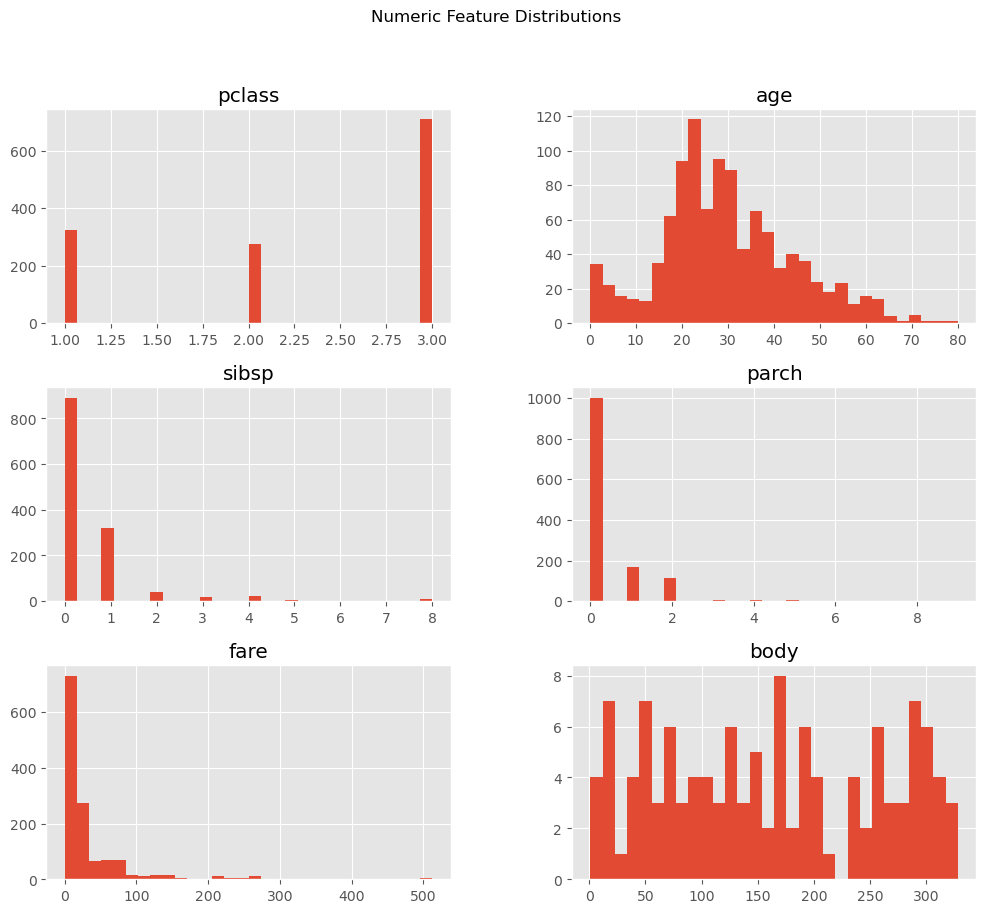

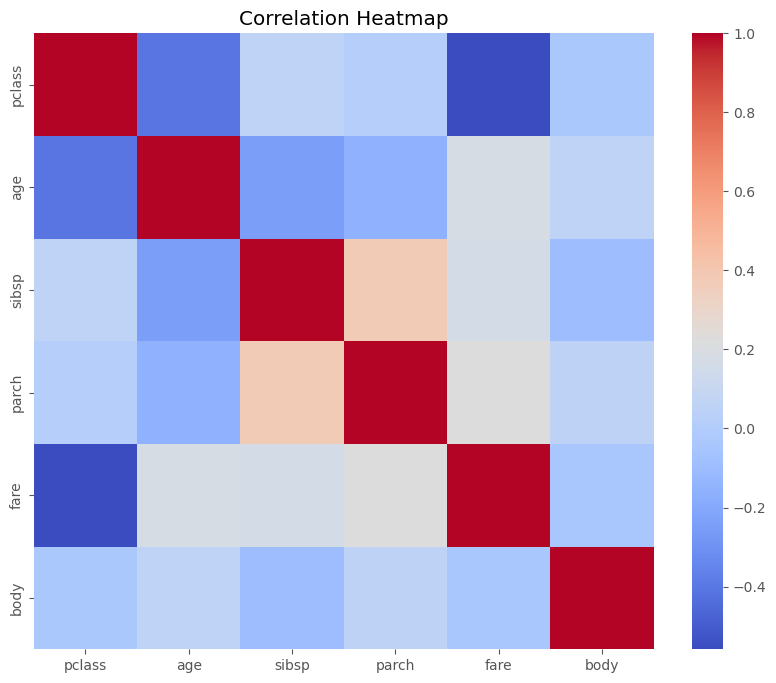

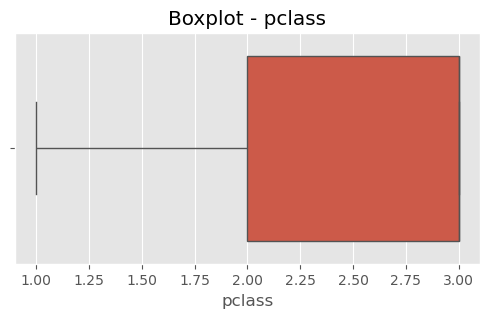

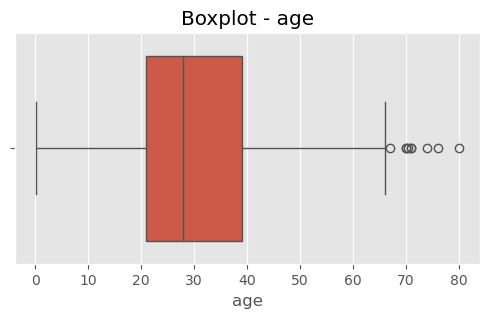

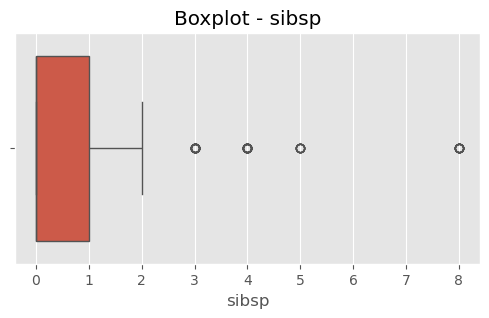

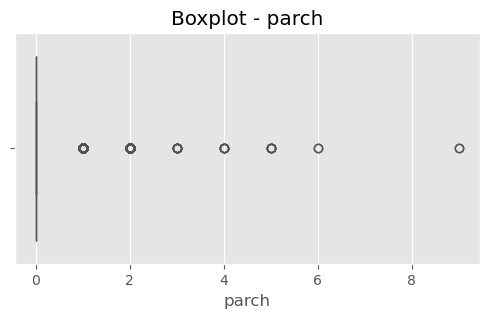

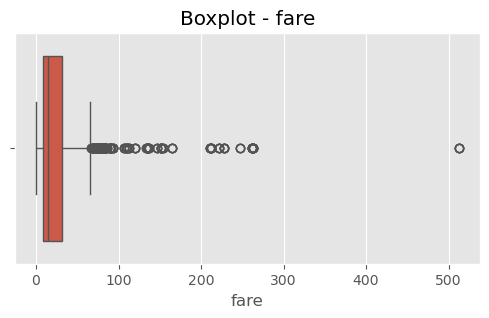

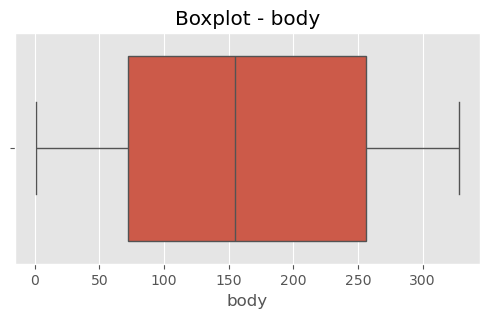


EDA 완료


In [9]:
# ===============================
# 1. 라이브러리 로드
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ===============================
# 2. 데이터 로드
# ===============================
file_path = "titanic_X.csv"
df = pd.read_csv(file_path)

# ===============================
# 3. 기본 정보
# ===============================
print("===== Shape =====")
print(df.shape)

print("\n===== Columns =====")
print(df.columns)

print("\n===== Info =====")
print(df.info())

print("\n===== Describe =====")
print(df.describe())

# ===============================
# 4. 결측치 확인
# ===============================
print("\n===== Missing Values =====")
missing = df.isnull().sum()
missing_ratio = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_ratio(%)": missing_ratio
})

print(missing_df.sort_values("missing_ratio(%)", ascending=False))

# ===============================
# 5. 중복 데이터
# ===============================
print("\n===== Duplicates =====")
print(df.duplicated().sum())

# ===============================
# 6. 범주형 변수 분석
# ===============================
cat_cols = df.select_dtypes(include=['object','category']).columns

print("\n===== Categorical Columns =====")
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))

# ===============================
# 7. 수치형 변수 분석
# ===============================
num_cols = df.select_dtypes(include=[np.number]).columns

print("\n===== Numeric Columns =====")
print(num_cols)

# ===============================
# 8. 히스토그램
# ===============================
df[num_cols].hist(figsize=(12,10), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()

# ===============================
# 9. 상관관계
# ===============================
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 10. 박스플롯 (Outlier 확인)
# ===============================
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

print("\nEDA 완료")